# 步態 CSV 工作台

把這個專案能產生的硬體 CSV 集中在一個地方。**一種步態一個標題**，
那個標題底下就有它的全部：參數、生成、檢查、圖。

**這裡不重新實作任何 planner。** 每個產生器都是你在命令列會跑的同一支 driver，
這個 notebook 只負責餵參數、讀結果。
**如果這裡的數字跟 driver 跑出來的不一致，以 driver 為準。**

## 命名規則

```
<家族>_<地形>[_V<速度>]_v<版號>
        例：hybrid_flat_v1、hybrid_flat_V150_v1、hybrid_obstacle_v1
```

**大寫 `V` 是速度（mm/s），小寫 `v` 是版號。** 兩者同時出現時速度在前，
因為比較實驗是「同一個速度下的三種步態」，速度是分組的軸。

`V` 只在**為了某個比較基準而釘住速度**時才寫。沒有 `V` 的名字表示用 driver 的
預設週期（hybrid 平地是 2.4 s，車速 159.763 mm/s —— 一個算出來的餘數，不是選的）。

版號在**步態本身改變**時才加（姿態、duty、週期的預設值、或 planner 換了做法）。
只是換 `--metres` 或 `--out` 不算新版本 —— 那是同一個步態的不同一次生成。
**換速度也不算新版本**，那是 `V` 在管的事。

檔案一律寫進 `notes/day13/`，三個一組：

```
<name>.csv           12 欄硬體 CSV
<name>_phase.csv     逐列對齊的 stance(0)/swing(1)
<name>_summary.csv   這次跑的參數與結果
```

## 目錄

| 步態 | 地形 | 狀態 | 章節 |
|---|---|---|---|
| `hybrid_flat_v1` | 平地 | Step 9 全過，可執行 | [§1](#1-hybrid_flat_v1) |
| `hybrid_flat_V150_v1` | 平地 | 同上，速度釘在 150 mm/s | [§1.5](#15-釘住速度的版本) |
| `hybrid_obstacle_v1` | 障礙物 | **還不能匯出**，6 項驗證失敗 | [§2](#2-hybrid_obstacle_v1未完成) |

Walk / trot / lean / transform 的產生器在 `examples/gait/`，
它們有自己的 UI，這裡**刻意不包進來**。

## CSV 契約（所有步態共用）

```
12 欄，無表頭
  欄 0-7     (theta, beta) x 4 腿，專案腿索引 0 FL / 1 FR / 2 RR / 3 RL
  欄 8-11    gamma，固定 0
列 0..4999   cosine prep ramp，從折疊 home 姿態（theta = 17 度）拉到第一幀
列 5000..    步態本身，1 kHz
```


---

## 共用工具

下面三格是所有步態共用的。加新步態**不需要動這裡**。

In [6]:
import subprocess, sys, csv
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

ROOT = Path("/home/chang/corgi_ws/icra hybrid/LegWheel")
NOTES = ROOT / "hybrid_note" / "notes"
DAY13 = NOTES / "day13"
EXPERIMENTS = ROOT / "hybrid_note" / "scripts" / "experiments"

MOTOR_LIMIT_DEG_S = 1980.0     # 330 rpm，兩個關節共用這一個預算
CONTROLLER_HZ = 1000.0
PREP_ROWS = 5000

# 圖上的中文字型。matplotlib 預設的 DejaVu Sans 沒有漢字，不設就會變成空框。
# 這裡是【偵測】不是寫死：挑第一個系統真的有的，都沒有就退回英文標籤。
_CJK = ["Noto Sans CJK TC", "Noto Sans CJK SC", "Noto Serif CJK TC",
        "Droid Sans Fallback", "WenQuanYi Zen Hei", "Microsoft JhengHei"]
_have = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONT = next((f for f in _CJK if f in _have), None)
if CJK_FONT:
    matplotlib.rcParams["font.family"] = [CJK_FONT, "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False   # 負號在 CJK 字型裡常缺字
print("圖用字型：", CJK_FONT or "找不到中文字型，圖上的標籤會退回英文")

圖用字型： Droid Sans Fallback


In [7]:
@dataclass(frozen=True)
class Gait:
    """一種步態在這個工作台裡的全部登記資料。

    加一種新步態 = 在 GAITS 加一個 Gait，不必複製任何 cell。
    """

    name: str                       # 也是輸出檔名，例如 hybrid_flat_v1
    driver: str                     # experiments/ 底下的檔名
    terrain: str
    status: str
    runnable: bool
    defaults: dict = field(default_factory=dict)
    knobs: tuple = ()               # (旗標, 預設, 說明)
    note: str = ""

    @property
    def driver_path(self):
        return EXPERIMENTS / self.driver

    def files(self):
        return (DAY13 / f"{self.name}.csv",
                DAY13 / f"{self.name}_phase.csv",
                DAY13 / f"{self.name}_summary.csv")

    def exists(self):
        return all(p.exists() for p in self.files())


GAITS: dict[str, Gait] = {}


def register(gait: Gait) -> Gait:
    GAITS[gait.name] = gait
    return gait


def catalogue():
    print(f"{'步態':22s} {'地形':8s} {'可執行':7s} {'已生成':7s} 狀態")
    print("-" * 100)
    for g in GAITS.values():
        print(f"{g.name:22s} {g.terrain:8s} {'是' if g.runnable else '否':7s} "
              f"{'是' if g.exists() else '否':7s} {g.status}")

In [8]:
def generate(gait, **overrides):
    """跑這個步態的 driver。overrides 的 key 是旗標名去掉 '--'。"""
    if isinstance(gait, str):
        gait = GAITS[gait]
    if not gait.runnable:
        raise RuntimeError(f"{gait.name} 目前不能匯出：{gait.status}")
    args = {**gait.defaults, **overrides}
    args.setdefault("out", gait.name)
    cmd = [sys.executable, "-u", str(gait.driver_path)]
    for key, value in args.items():
        if value is None:
            continue
        cmd += [f"--{key.replace('_', '-')}", str(value)]
    print(" ".join(cmd[2:]), "\n")
    done = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
    print(done.stdout)
    if done.returncode != 0:
        print(done.stderr[-3000:])
        raise RuntimeError(f"driver 失敗（return code {done.returncode}）")
    return done.stdout


def load(name):
    name = name.name if isinstance(name, Gait) else name
    csv_path, phase_path, summary_path = GAITS[name].files()
    rows = np.loadtxt(csv_path, delimiter=",")
    phase = np.loadtxt(phase_path, delimiter=",", skiprows=1)
    with summary_path.open() as fh:
        summary = list(csv.DictReader(fh))[0]
    return rows, phase, summary


def describe(name):
    name = name.name if isinstance(name, Gait) else name
    rows, phase, summary = load(name)
    theta, beta = rows[:, [0, 2, 4, 6]], rows[:, [1, 3, 5, 7]]
    rate = np.rad2deg((np.abs(np.diff(theta, axis=0))
                       + np.abs(np.diff(beta, axis=0))) * CONTROLLER_HZ)
    traj = rate[PREP_ROWS:]
    print(f"{name}")
    print(f"  列 x 欄            {rows.shape[0]} x {rows.shape[1]}")
    print(f"  prep / 軌跡        {PREP_ROWS} / {rows.shape[0] - PREP_ROWS}"
          f"  （{(rows.shape[0] - PREP_ROWS) / CONTROLLER_HZ:.3f} 秒）")
    print(f"  走的距離           {float(summary['metres_delivered']):.4f} m")
    print(f"  車速               {float(summary['body_speed_mm_s']):.3f} mm/s")
    print(f"  duty / 週期        {summary['stance_duty']} / {summary['cycle_period_s']} s")
    print(f"  馬達峰值           {traj.max():.1f} deg/s"
          f"  （330 rpm 的 {traj.max() / MOTOR_LIMIT_DEG_S * 100:.1f}%）")
    print(f"  超過上限的列       {(traj > MOTOR_LIMIT_DEG_S).sum()}")
    print(f"  Step 9 失敗項      {summary['step9_failed_checks'] or '無'}")
    # 契約是【檢查】出來的，不是假設的
    print(f"  row0 theta = 17 度        {np.allclose(np.rad2deg(rows[0, [0,2,4,6]]), 17.0)}")
    print(f"  prep 與軌跡接得上          {np.allclose(rows[PREP_ROWS-1], rows[PREP_ROWS])}")
    print(f"  gamma 四欄全為 0           {np.allclose(rows[:, 8:], 0.0)}")
    return rows, phase, summary


_LEGS = ["FL (LF)", "FR (RF)", "RR (RH)", "RL (LH)"]
_T = (lambda zh, en: zh if CJK_FONT else en)


def plot(name, seconds=6.0):
    name = name.name if isinstance(name, Gait) else name
    rows, phase, _ = load(name)
    traj, ph = rows[PREP_ROWS:], phase[PREP_ROWS:]
    n = min(int(seconds * CONTROLLER_HZ), len(traj))
    t = np.arange(n) / CONTROLLER_HZ

    fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
    for i, leg in enumerate(_LEGS):
        axes[0].plot(t, np.rad2deg(traj[:n, 2 * i]), label=leg, lw=1.2)
        axes[1].plot(t, np.rad2deg(traj[:n, 2 * i + 1]), label=leg, lw=1.2)
    axes[0].set_ylabel("theta [deg]"); axes[0].legend(ncol=4, fontsize=8)
    axes[1].set_ylabel("beta [deg]")
    # 離地帶狀圖：讓步態的交錯【看得見】，而不是用講的
    for i in range(4):
        axes[2].fill_between(t, i, i + 0.8, where=ph[:n, i] > 0, step="mid", alpha=0.7)
    axes[2].set_yticks(np.arange(4) + 0.4); axes[2].set_yticklabels(_LEGS)
    axes[2].set_xlabel(_T("trigger 之後的時間 [s]", "time after trigger [s]"))
    axes[2].set_ylabel(_T("離地", "airborne"))
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.suptitle(name); fig.tight_layout()
    return fig


def plot_rate(name):
    name = name.name if isinstance(name, Gait) else name
    rows, _, _ = load(name)
    traj = rows[PREP_ROWS:]
    theta, beta = traj[:, [0, 2, 4, 6]], traj[:, [1, 3, 5, 7]]
    rate = np.rad2deg((np.abs(np.diff(theta, axis=0))
                       + np.abs(np.diff(beta, axis=0))) * CONTROLLER_HZ)
    t = np.arange(len(rate)) / CONTROLLER_HZ

    fig, ax = plt.subplots(figsize=(11, 3.2))
    for i, leg in enumerate(_LEGS):
        ax.plot(t, rate[:, i], lw=0.8, label=leg)
    ax.axhline(MOTOR_LIMIT_DEG_S, color="crimson", ls="--", lw=1.2,
               label=_T("330 rpm 上限", "330 rpm limit"))
    ax.set_xlabel(_T("trigger 之後的時間 [s]", "time after trigger [s]"))
    ax.set_ylabel("|dtheta| + |dbeta|  [deg/s]")
    ax.set_title(_T(f"{name} —— 兩個關節共用一個預算",
                    f"{name} -- the two joints share one budget"))
    ax.legend(ncol=5, fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout()
    return fig


def show_knobs(gait):
    if isinstance(gait, str):
        gait = GAITS[gait]
    print(f"{gait.name} 的旗標\n")
    print(f"{'旗標':18s} {'預設值':30s} 說明")
    print("-" * 110)
    for flag, default, note in gait.knobs:
        print(f"{flag:18s} {str(default):30s} {note}")
    if gait.note:
        print(f"\n{gait.note}")

---

# 1. `hybrid_flat_v1`

平地上的 Hybrid nominal locomotion：`FOOT_RIM_ROLL → RECOVERY_SWING` 連續 cycle，
四腳每 0.6 秒交錯一隻離地，順序 LF → RH → RF → LH。

**狀態：Step 9 全過，可以上機／進模擬。**

版本定義（v1 就是這一組）：

```
姿態      theta 60 度，守住滾動弧最高點 219.4478 mm（水平化滾動）
步態      duty 0.85，週期 2.4 s
車速      159.763 mm/s = cycle 髖部前進 383.431 mm / 2.4 s
馬達      峰值 95.0% of 330 rpm
```

In [9]:
hybrid_flat_v1 = register(Gait(
    name="hybrid_flat_v1",
    driver="day13_step3_hardware_driver.py",
    terrain="平地",
    status="Step 9 全過，可執行",
    runnable=True,
    defaults=dict(metres=3.0, planner_hz=200.0),
    knobs=(
        ("--metres",        3.0,   "要走多遠；cycle 數由車速自己算出來"),
        ("--period",        2.4,   "週期（秒）。車速 = cycle 髖部前進 / 週期，"
                                   "所以這是唯一的直接速度旋鈕"),
        ("--speed-mm-s",    None,  "【改成指定車速】，週期由它【解】出來而不是打進去。"
                                   "要釘住比較基準就用這個 —— 把週期當字面值寫死，"
                                   "在 theta / duty / roll-step 改變的那一刻就會"
                                   "安靜地不再是那個速度。會蓋掉 --period"),
        ("--duty",          0.85,  "stance duty。0.75 是【臨界 duty】，"
                                   "縱向 support margin 在那裡恆等於零"),
        ("--theta-deg",     60.0,  "姿態 theta。會改變滾動 stroke 的長度，也就改變車速"),
        ("--hold-hip-z-mm", None,  "守住的髖高。預設 = 滾動弧的最高點，"
                                   "那正是讓四隻站立腳對車體高度取得一致的值"),
        ("--roll-step-mm",  4.0,   "每個生成步的接觸前進。建構時間跟它成反比"),
        ("--planner-hz",    200.0, "重取樣到 1 kHz 之前的 planner 網格。"
                                   "馬達峰值要夠細才會【收斂】"),
        ("--out",           "hybrid_flat_v1", "輸出檔名（放在 notes/day13/）"),
    ),
    note=("其中兩個不是自由參數：\n"
          "  duty 0.75 是四足 wave gait 的臨界值，margin 正比於 duty - 3/4，"
          "在那裡【依定義】為零。\n"
          "  period 直接除進馬達速率，而預設 2.4 s 下峰值已經 95.0% —— "
          "往快的方向幾乎沒有空間。\n\n"
          "--period 與 --speed-mm-s 是【同一個旋鈕的兩種問法】，給了後者就以後者為準。\n"
          "  車速 = cycle 髖部前進 / 週期，而髖部前進【不隨週期改變】，\n"
          "  所以解週期是一次除法，不是迭代。"),
))

show_knobs(hybrid_flat_v1)

hybrid_flat_v1 的旗標

旗標                 預設值                            說明
--------------------------------------------------------------------------------------------------------------
--metres           3.0                            要走多遠；cycle 數由車速自己算出來
--period           2.4                            週期（秒）。車速 = cycle 髖部前進 / 週期，所以這是【唯一】的直接速度旋鈕
--duty             0.85                           stance duty。0.75 是【臨界 duty】，縱向 support margin 在那裡恆等於零
--theta-deg        60.0                           姿態 theta。會改變滾動 stroke 的長度，也就改變車速
--hold-hip-z-mm    None                           守住的髖高。預設 = 滾動弧的最高點，那正是讓四隻站立腳對車體高度取得一致的值
--roll-step-mm     4.0                            每個生成步的接觸前進。建構時間跟它成反比
--planner-hz       200.0                          重取樣到 1 kHz 之前的 planner 網格。馬達峰值要夠細才會【收斂】
--out              hybrid_flat_v1                 輸出檔名（放在 notes/day13/）

其中兩個不是自由參數：
  duty 0.75 是四足 wave gait 的臨界值，margin 正比於 duty - 3/4，在那裡【依定義】為零。
  period 直接除進馬達速率，而預設 2.4 s 下峰值已經 95.0% —— 往快的方向幾乎沒有空間。


### 1.1 生成

In [10]:
# 會跑幾分鐘：滾動 stroke 是對著真實接觸幾何一步一步生成的，不是公式取樣。
generate(hybrid_flat_v1)

/home/chang/corgi_ws/icra hybrid/LegWheel/hybrid_note/scripts/experiments/day13_step3_hardware_driver.py --metres 3.0 --planner-hz 200.0 --out hybrid_flat_v1 



posture           theta 60.000 deg   hold hip_z 219.4478 mm   roll step 4.000 mm
gait              duty 0.850   period 2.400 s
body speed          159.763 mm/s
asked for             3.000 m  -> 18.778 s
cycles to build   9
covered interval    -0.2400 .. 19.5600 s   span 19.8000 s
distance covered     3.1633 m
planner samples   3961  (200 Hz)
Step 9            0 failed check(s)  []

the CSV, in the Walk pipeline's contract
  rows                     24796
  prep_rows                5000
  trajectory_rows          19796
  controller_dt_s          0.001
  planner_dt_s             0.004998737692501892
  resample_ratio           1
  duration_s               24.796
  trajectory_duration_s    19.796
  columns 0-7              (theta, beta) per leg, project index 0 FL / 1 FR / 2 RR / 3 RL
  columns 8-11             gamma, fixed at 0 (Day 12 fixes it there)
  travel over trajectory   3.1627 m
  peak |dtheta|+|dbeta|    1881.61 deg/s   (95.0% of 330 rpm)

wrote -> /home/chang/corgi_ws/icra hybri

"posture           theta 60.000 deg   hold hip_z 219.4478 mm   roll step 4.000 mm\ngait              duty 0.850   period 2.400 s\nbody speed          159.763 mm/s\nasked for             3.000 m  -> 18.778 s\ncycles to build   9\ncovered interval    -0.2400 .. 19.5600 s   span 19.8000 s\ndistance covered     3.1633 m\nplanner samples   3961  (200 Hz)\nStep 9            0 failed check(s)  []\n\nthe CSV, in the Walk pipeline's contract\n  rows                     24796\n  prep_rows                5000\n  trajectory_rows          19796\n  controller_dt_s          0.001\n  planner_dt_s             0.004998737692501892\n  resample_ratio           1\n  duration_s               24.796\n  trajectory_duration_s    19.796\n  columns 0-7              (theta, beta) per leg, project index 0 FL / 1 FR / 2 RR / 3 RL\n  columns 8-11             gamma, fixed at 0 (Day 12 fixes it there)\n  travel over trajectory   3.1627 m\n  peak |dtheta|+|dbeta|    1881.61 deg/s   (95.0% of 330 rpm)\n\nwrote -> /home/

### 1.2 檢查

In [11]:
describe(hybrid_flat_v1);

hybrid_flat_v1
  列 x 欄            24796 x 12
  prep / 軌跡        5000 / 19796  （19.796 秒）
  走的距離           3.1627 m
  車速               159.763 mm/s
  duty / 週期        0.85 / 2.4 s
  馬達峰值           1881.7 deg/s  （330 rpm 的 95.0%）
  超過上限的列       0
  Step 9 失敗項      無
  row0 theta = 17 度        True
  prep 與軌跡接得上          True
  gamma 四欄全為 0           True


### 1.3 圖

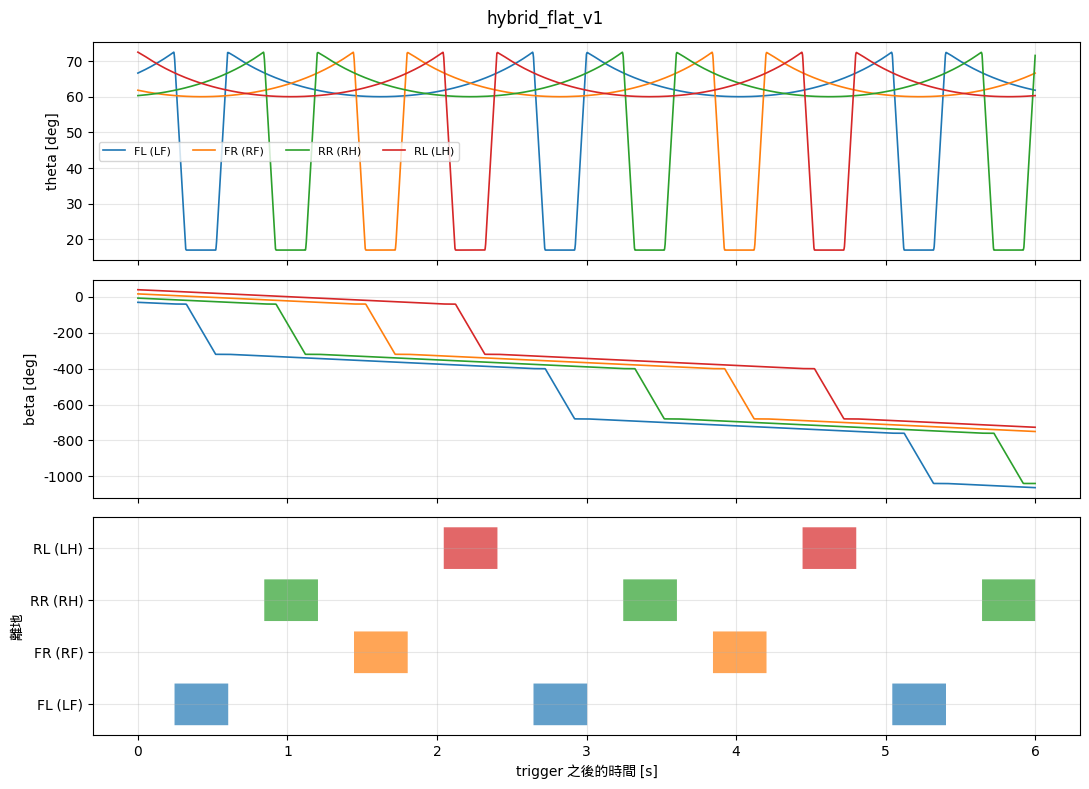

In [12]:
plot(hybrid_flat_v1);

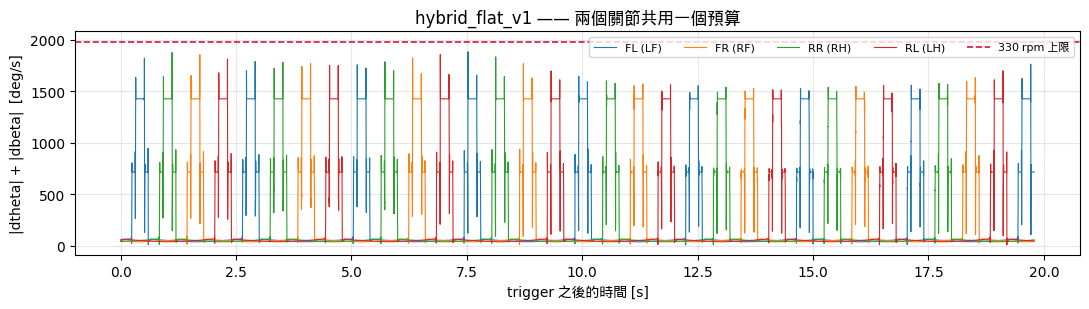

In [13]:
plot_rate(hybrid_flat_v1);

### 1.4 掃旋鈕

已經量過的一組（`--metres 1.0`）：

```
週期 2.4 s   車速 159.763 mm/s   峰值 1881.6 deg/s   95.0%
週期 3.0 s   車速 127.810 mm/s   峰值 1489.3 deg/s   75.2%
```

**週期與馬達峰值幾乎成反比。** 兩點外推，要回到 80% 以下週期大約要 2.85 s 以上。

In [14]:
# 要跑再解除註解 —— 每個點都是一次完整生成，要幾分鐘。
# 注意 out 要給不同的名字，否則會互相覆蓋。
#
# for period in (2.4, 2.8, 3.2):
#     generate(hybrid_flat_v1, metres=1.0, period=period, planner_hz=50,
#              out=f"probe_period{period}")

---

## 1.5 釘住速度的版本

`hybrid_flat_v1` 的預設車速 **159.763 mm/s** 不是選出來的，是掉出來的：

```
cycle 髖部前進 383.4303 mm  ÷  週期 2.4 s  =  159.763 mm/s
```

那 383.43 mm 又是 `stroke 325.916 + recovery 57.515` 的和，兩個都由輪緣幾何與
duty 決定。所以要三種步態在**同一個速度**下比較，就得反過來做：先選速度，再解週期。

`--speed-mm-s` 就是這件事。150 mm/s 下：

| | `hybrid_flat_v1` | `hybrid_flat_V150_v1` |
|---|---|---|
| 車速 | 159.763 mm/s | **150.000 mm/s** |
| 週期 | 2.4 s | 2.556202 s（解出來的） |
| 馬達峰值 | 1881.61 deg/s（95.0%） | **1739.23 deg/s（87.8%）** |
| 軌跡列數 | 19796 | 21084 |
| Step 9 失敗 | 0 | **0** |

姿態、duty、roll step 全部沒動 —— **只有時間被拉長**。

> 慢下來只會讓馬達更輕鬆，所以 150 mm/s 不需要重新確認可行性；
> 但反過來（要更快）會直接撞上 1980 deg/s，那必須重跑。


`V150` 版**共用同一個 `Gait` 登記**（同一支 driver、同一組旗標），
只是多帶一個 `--speed-mm-s`。所以這裡註冊的是**輸出檔名**，不是新步態：


In [ ]:
hybrid_flat_V150_v1 = register(Gait(
    name="hybrid_flat_V150_v1",
    driver="day13_step3_hardware_driver.py",
    terrain="平地",
    status="Step 9 全過；速度釘在 150 mm/s 供三步態比較",
    runnable=True,
    defaults=dict(metres=3.0, planner_hz=200.0, speed_mm_s=150.0),
    # 同一組旗標，只有 --out 的預設不同（generate() 會用 name 當 out）。
    knobs=tuple(("--out", "hybrid_flat_V150_v1", note) if flag == "--out"
                else (flag, default, note)
                for flag, default, note in hybrid_flat_v1.knobs),
    note=("跟 hybrid_flat_v1 是【同一個步態】，只是速度基準不同 —— "
          "所以版號一樣是 v1。\n"
          "比較用的 walk / wheel 也應該用同一個 --speed-mm-s 150。"),
))

catalogue()

In [ ]:
# 已經生成過了，要重跑再解除註解（約兩分鐘）。
# generate(hybrid_flat_v1, speed_mm_s=150, out="hybrid_flat_V150_v1")

describe("hybrid_flat_V150_v1");

---

# 2. `hybrid_obstacle_v1`（未完成）

越障。**目前生不出 CSV**，登記在這裡是為了讓狀態有地方寫，
而不是散在 log 裡。

`generate("hybrid_obstacle_v1")` 會直接擋下來並說明原因。

## 為什麼還不能匯出

40 mm x 400 mm 障礙物下，Step 9 有 6 項失敗：

```
at_most_one_airborne        出口過渡兩腳同時離地
three_support_legs          上一項的後果
body_requirement_satisfied  16 個瞬間有兩個互相矛盾的硬需求
segment_chaining            Day 10-11 序列內部的接觸換特徵（108.5 mm）
motor_rate_limit            phi_r 超過 330 rpm
support_margin              -23.5 mm
```

其中兩項是**幾何鎖死**的，不是調參數能解：

- 同一個 `mount_x` 的兩隻腳（前腳對、後腳對）髖永遠在同一個 x，
  障礙物在固定的世界 x，所以它們**必然同時越障**；
- 越障佔 658 mm 的髖部行程 > 軸距 510 mm，所以前腳還在下坡時後腳已經在上坡，
  兩邊要求的車體高度差到 54 mm —— 那需要**俯仰**，而 2D 模型沒有這個自由度。

詳見 `notes/day12/day12_implementation_log_zh_TW.md` §1.19–1.21。

In [15]:
hybrid_obstacle_v1 = register(Gait(
    name="hybrid_obstacle_v1",
    driver="day13_step3_hardware_driver.py",   # 之後換成越障專用的 driver
    terrain="障礙物",
    status="還不能匯出：Step 9 有 6 項失敗，其中 2 項是幾何鎖死",
    runnable=False,
))

catalogue()

步態                     地形       可執行     已生成     狀態
----------------------------------------------------------------------------------------------------
hybrid_flat_v1         平地       是       是       Step 9 全過，可執行
hybrid_obstacle_v1     障礙物      否       否       還不能匯出：Step 9 有 6 項失敗，其中 2 項是幾何鎖死


---

# 附錄：之後要加新的步態

保持同一個形狀，這個 notebook 才會一直好找，而不是變成一堆散落的 cell。

**一、driver 那邊**（`hybrid_note/scripts/experiments/`）

1. 產生器是一支**有 argparse 旗標的 driver**，不是寫在 cell 裡的程式碼；
2. 它把 `<name>.csv`、`<name>_phase.csv`、`<name>_summary.csv`
   寫進 `notes/day13/`，用最上面那份 12 欄契約；
3. summary CSV 要帶著讀者判斷這次跑得好不好所需要的欄位 ——
   `metres_delivered`、`body_speed_mm_s`、`stance_duty`、`cycle_period_s`、
   `step9_failed_checks`（`describe()` 讀的就是這幾個）。

**二、notebook 這邊**

4. 開一個新的 `# N. <名字>` 標題，底下放：版本定義 → `register(Gait(...))`
   → 生成 → 檢查 → 圖 → 掃旋鈕；
5. 在最上面的目錄表加一列；
6. **不要動「共用工具」那三格。** 如果覺得非動不可，那通常表示新步態的
   輸出沒有照契約走 —— 先修 driver。

做到這些，`generate()`、`describe()`、`plot()`、`plot_rate()` 不用改就能用。

**命名**：`<家族>_<地形>_v<版號>`。版號在**步態本身改變**時才加
（姿態、duty、週期的預設值、或 planner 換了做法）；
只是換 `--metres` 不算新版本。